# Interactive Visualization of DBSCAN Clustering

Inspired by Naftali Harris's interactive DBSCAN visualization (https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/), this notebook demonstrates the step-by-step process of the Density-Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm.

This notebook covers:
1. Generating a non-linear dataset (`make_moons`) perfect for density-based clustering.
2. Implementing a stepwise DBSCAN generator that yields the algorithm's state at every iteration.
3. Visualizing how DBSCAN discovers core points, reachable points, and noise through an epsilon ($\epsilon$) neighborhood search.
4. Exporting the animation to a high-quality GIF in the `animations` folder.

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import HTML
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 1. Generating Non-Linear Data (Moons Dataset)

DBSCAN is widely used for datasets where the clusters are not linearly separable or have arbitrary shapes. The `make_moons` dataset is a classic example where algorithms like K-Means fail, but density-based algorithms succeed.

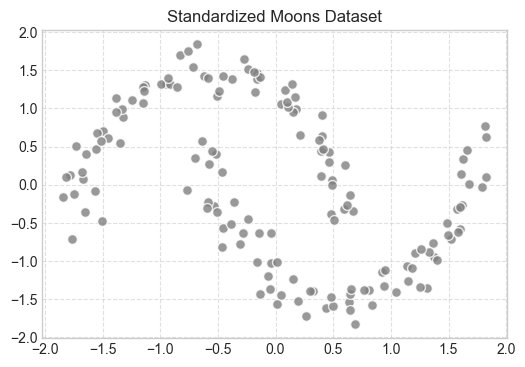

In [7]:
# Generate 150 points in a two-moon shape with some noise
X, true_labels = make_moons(n_samples=150, noise=0.08, random_state=RANDOM_STATE)

# Standardize the dataset for distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', s=50, alpha=0.8, edgecolors='w')
ax.set_title("Standardized Moons Dataset")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. Step-by-Step DBSCAN Implementation

To animate the process, we need to track the internal state of DBSCAN. Unlike `sklearn`'s highly-optimized implementation, we'll write a simple generator that yields its state whenever a point is evaluated or assigned to a cluster.

In [8]:
def dbscan_generator(X, eps, min_samples):
    """
    Step-by-step DBSCAN algorithm generator for animation purposes.
    Maintains and yields the classification state:
    0  : Unvisited / Unclassified
    -1 : Noise
    >0 : Cluster ID
    """
    n = X.shape[0]
    visited = np.zeros(n, dtype=bool)
    labels = np.zeros(n, dtype=int)
    
    # Precompute distances using NearestNeighbors for efficiency
    nn_model = NearestNeighbors(radius=eps).fit(X)
    cluster_id = 0
    
    for p in range(n):
        if visited[p]:
            continue
            
        visited[p] = True
        neighbors = nn_model.radius_neighbors([X[p]], return_distance=False)[0]
        
        # Point P is evaluated. If not enough neighbors, mark as noise
        if len(neighbors) < min_samples:
            labels[p] = -1
            # YIELD: Visiting a point and classifying it as noise (red search circle)
            yield {
                "current": p, 
                "neighbors": neighbors, 
                "labels": labels.copy(), 
                "eps": eps, 
                "min_samples": min_samples
            }
        else:
            # We found a new core point
            cluster_id += 1
            labels[p] = cluster_id
            
            # YIELD: New core point discovered (green search circle)
            yield {
                "current": p, 
                "neighbors": neighbors, 
                "labels": labels.copy(), 
                "eps": eps, 
                "min_samples": min_samples
            }
            
            # Expand the cluster
            seed_list = list(neighbors)
            if p in seed_list:
                seed_list.remove(p)
                
            i = 0
            while i < len(seed_list):
                q = seed_list[i]
                q_neighbors = nn_model.radius_neighbors([X[q]], return_distance=False)[0]
                
                if not visited[q]:
                    visited[q] = True
                    
                    # If this reachable point is also a core point, add its neighbors to the seed list
                    if len(q_neighbors) >= min_samples:
                        for n_p in q_neighbors:
                            if n_p not in seed_list and n_p != p:
                                seed_list.append(n_p)
                                
                    # YIELD: Visiting a point during cluster expansion
                    yield {
                        "current": q, 
                        "neighbors": q_neighbors, 
                        "labels": labels.copy(), 
                        "eps": eps, 
                        "min_samples": min_samples
                    }
                    
                # Assign to cluster if it is unclassified or previously marked as noise
                if labels[q] == 0 or labels[q] == -1:
                    labels[q] = cluster_id
                    
                i += 1

# Hyperparameters for DBSCAN
EPSILON = 0.3
MIN_SAMPLES = 5

# Consume the generator to record the history of states
history = list(dbscan_generator(X_scaled, eps=EPSILON, min_samples=MIN_SAMPLES))
print(f"Total algorithm steps recorded: {len(history)}")
print(f"Number of clusters found: {np.max(history[-1]['labels'])}")

Total algorithm steps recorded: 150
Number of clusters found: 3


## 3. Animating the Neighborhood Search

This animation replicates the visual experience of determining core points and reachable points. 
- **Light Gray**: Unvisited points
- **Black**: Noise/Outliers
- **Colored Points**: Cluster members (e.g., Blue, Orange, Green)
- **Circle Outline**: Represents the $\epsilon$-neighborhood search region for the current point.

In [9]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Standardized Core Colors to match other notebooks
base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
dark_colors = ['#0f3b5a', '#803f07', '#165016', '#721515', '#4f3666', '#4a2c26']

# Colors: 0=Unvisited(gray), -1=Noise(black), 1,2,3...=Clusters
cluster_colors = {
    0:  '#cccccc', # Light gray for unvisited
    -1: '#111111', # Black for noise
}
# Dynamically add cluster colors
num_clusters = np.max(history[-1]['labels'])
for i in range(1, num_clusters + 1):
    cluster_colors[i] = base_colors[(i - 1) % len(base_colors)]

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
ax.set_title("DBSCAN Clustering Iterations", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Feature 1", fontsize=12)
ax.set_ylabel("Feature 2", fontsize=12)

# Set static limits based on the dataset
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Matching grid style
ax.grid(True, linestyle='--', alpha=0.6, zorder=1)

# Elements to animate
scatter_points = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', s=45, alpha=0.9, edgecolors='k', zorder=5)
search_circle = Circle((0, 0), radius=EPSILON, fill=True, color='purple', alpha=0.15, ec='purple', lw=2, zorder=4)
current_point_marker, = ax.plot([], [], 'o', color='none', markeredgecolor='magenta', markersize=12, markeredgewidth=2, zorder=10)

ax.add_patch(search_circle)

# Top center text matching others
title_text = ax.text(0.5, 0.98, '', transform=ax.transAxes, ha='center', fontsize=12, 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', zorder=20))

# Create Legend matching other notebooks
legend_patches = [
    Patch(facecolor=cluster_colors[0], edgecolor='#888888', label='Unvisited'),
    Patch(facecolor=cluster_colors[-1], edgecolor='white', label='Noise')
]
for i in range(1, num_clusters + 1):
    legend_patches.append(Patch(facecolor=cluster_colors[i], edgecolor=dark_colors[(i - 1) % len(dark_colors)], label=f'Cluster {i}'))

ax.legend(handles=legend_patches, title="DBSCAN Labels", loc='upper left', frameon=True, 
          facecolor='white', framealpha=0.9).set_zorder(20)

def init():
    scatter_points.set_color([cluster_colors[0]] * len(X_scaled))
    scatter_points.set_edgecolors('k')
    search_circle.set_visible(False)
    current_point_marker.set_data([], [])
    title_text.set_text('')
    return scatter_points, search_circle, current_point_marker, title_text

def animate(frame_idx):
    state = history[frame_idx]
    
    # 1. Update point colors
    colors = [cluster_colors.get(lbl, '#333333') for lbl in state['labels']]
    scatter_points.set_color(colors)
    scatter_points.set_edgecolors('k')
    
    # 2. Update search circle
    curr_idx = state['current']
    curr_x, curr_y = X_scaled[curr_idx, 0], X_scaled[curr_idx, 1]
    
    search_circle.set_center((curr_x, curr_y))
    search_circle.set_visible(True)
    
    # Change circle color based on whether we found enough neighbors
    if len(state['neighbors']) >= state['min_samples']:
        search_circle.set_facecolor('#2ca02c') # Green tint for core point
        search_circle.set_edgecolor('#165016')
    else:
        search_circle.set_facecolor('#d62728') # Red tint for noise/border check
        search_circle.set_edgecolor('#8c1717')
        
    # 3. Highlight current point
    current_point_marker.set_data([curr_x], [curr_y])
    
    # 4. Update Header Text (matching other notebooks layout)
    status = 'Core' if len(state['neighbors']) >= state['min_samples'] else 'Noise/Border'
    title_text.set_text(f"Step: {frame_idx + 1} / {len(history)} | Status: {status} | Neighbors: {len(state['neighbors'])}")
    
    return scatter_points, search_circle, current_point_marker, title_text

# Subsample history if there are too many frames to keep GIF generation reasonably fast
step = max(1, len(history) // 300)
anim_frames = list(range(0, len(history), step))
if anim_frames[-1] != len(history) - 1:
    anim_frames.append(len(history) - 1)

# We use a lower fps (e.g. 10 instead of 15) to make the animation more deliberate
anim = FuncAnimation(fig, animate, init_func=init, frames=anim_frames, interval=100, blit=True)

# Important: Make sure the output directory exists
os.makedirs("../animations", exist_ok=True)
output_path = "../animations/dbscan_animation.gif"

print(f"Generating enhanced animation ({len(anim_frames)} frames). This might take a moment...")
# FPS aligned more with other notebooks, though slightly faster for DBSCAN step count
anim.save(output_path, writer=PillowWriter(fps=10))
print(f"Animation successfully saved to {output_path}")

plt.close(fig) # Prevent static plot display above the animation

Generating enhanced animation (150 frames). This might take a moment...
Animation successfully saved to ../animations/dbscan_animation.gif


## 4. Final Result

You can view the generated GIF directly inside the notebook or open the corresponding file via your notebook/markdown viewer!

In [10]:
# Display in notebook if possible
HTML(f'<img src="{output_path}" />')